# Desafio Ciência e Governança de Dados

Desenvolvido por Estevão Augusto da Fonseca Santos, Graduando em Ciência de Computação

6° Período da Universidade Federal de Lavras

## Objetivos

Tendo finalizado a seção de análise exploratória. Agora, é preciso desenvolver e testar um modelo de predição, a fim de checar a correlação de dados, e sua influência em Lavras.

In [20]:
from datetime import datetime                                   # 
import pandas as pd                                             # Manipulação e análise de dados em estruturas como DataFrames
import matplotlib.pyplot as plt                                 # Criação de gráficos 2D de forma flexível
import seaborn as sns                                           # Visualização de dados estatísticos com gráficos mais estilizados
from sklearn.metrics import silhouette_score                    #
import shap                                                     #
import numpy as np                                              # Biblioteca de manipulação de matrizes e vetores 
import plotly.graph_objects as go                               #
import plotly.express as px                                     #
from sklearn.ensemble import RandomForestRegressor              #
from sklearn.linear_model import LinearRegression               # Criação de modelos de regressão linear
from sklearn.cluster import KMeans                              # 
from sklearn.preprocessing import StandardScaler                # Padronização e normalização de dados
from sklearn.metrics import r2_score, mean_absolute_error       # Avaliação de desempenho de modelos com R²
import pickle                                                   # Salvar modelos de IA no computador de forma bruta
import joblib                                                   # 
import os                                                       # Interação com o sistema de arquivos e funcionalidades do sistema operacional
import sys                                                      # 

In [21]:
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))  # Adiciona raiz

# Define constantes que armazenam os caminhos que serão utilizados neste notebook
from config_path import RAW_DATA_DIRECTORY_PATH, PROCESSED_DATA_DIRECTORY_PATH, REPORTS_DIRECTORY_PATH
from config_path import METRICS_DIRECTORY_PATH, MODELS_DIRECTORY_PATH, FEATURES_DIRECTORY_PATH
from config_path import ROOT_DIR, INTERACTIVE_REPORTS_PATH

In [22]:
# Criação dos diretórios que serão utilizados no projeto

if not os.path.isdir(INTERACTIVE_REPORTS_PATH):
    os.mkdir(INTERACTIVE_REPORTS_PATH)

if not os.path.isdir(FEATURES_DIRECTORY_PATH):
    os.mkdir(FEATURES_DIRECTORY_PATH)

if not os.path.isdir(REPORTS_DIRECTORY_PATH): # Criar o diretório dos gráficos caso ele não tenha sido criado
    os.mkdir(REPORTS_DIRECTORY_PATH)

if not os.path.isdir(MODELS_DIRECTORY_PATH): # Criar o diretório dos modelos salvos caso ele não tenha sido criado
    os.mkdir(MODELS_DIRECTORY_PATH)
    
if not os.path.isdir(METRICS_DIRECTORY_PATH): # Criar o diretório das métricas dos modelos caso ele não tenha sido criado
    os.mkdir(METRICS_DIRECTORY_PATH)

In [75]:
df_municipios = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/tamanho_populacional_mun.csv")
df_alfabetizacao = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/alfabetizacao_processada.csv")
df_educacao = pd.read_csv(f"{RAW_DATA_DIRECTORY_PATH}/educacao_basica_sexo_raca_cor.csv")
df_geo = pd.read_csv(f"{RAW_DATA_DIRECTORY_PATH}/traducao_municipios.csv")

In [77]:
# Selecionar apenas as colunas relevantes de cada DataFrame
df_alfabetizacao = df_alfabetizacao[['id_municipio','nome_municipio','total_alfabetizados']]  # Total de alfabetizados por município
df_matriculas = df_educacao.groupby(['ano','id_municipio','id_municipio_nome'])['quantidade_matricula'].sum().reset_index()  # Soma das matrículas por município

# Merge sequencial dos DataFrames, combinando informações pelos IDs dos municípios
df = df_municipios.merge(df_alfabetizacao, on=['id_municipio'], how='inner')  # Adiciona dados de alfabetização
df = df.merge(df_matriculas, on=['id_municipio','ano'], how='inner')  # Adiciona dados de matrículas
df.rename(columns={ 'id_municipio_nome_x' : 'id_municipio_nome'}, inplace=True)
df.drop('id_municipio_nome_y', axis=1, inplace=True)


In [78]:
df = pd.merge(df, df_geo[['id_municipio', 'nome', 'centroide', 'nome_mesorregiao']], how="inner", on="id_municipio")
# Limpando o centroide para ter Latitude e Longitude numéricas
df['longitude'] = df['centroide'].str.extract(r'POINT\((.*) ').astype(float)
df['latitude'] = df['centroide'].str.extract(r' (.*)\)').astype(float)

In [79]:
# -------------------------------
# Criar colunas normalizadas (antes de qualquer análise)
# -------------------------------
# Evitar divisão por zero caso populacao_total tenha zeros
df['pib_per_capita'] = df['pib'] / df['populacao_total']
df['va_per_capita'] = df['valor_adicionado_precos_correntes_total'] / df['populacao_total']
df['taxa_alfabetizacao'] = df['total_alfabetizados'] / df['populacao_total']
df['taxa_matricula'] = df['quantidade_matricula'] / df['populacao_total']
df['densidade_populacional'] = df['populacao_total'] / df['AR_MUN_2024']
df['participacao_impostos'] = df['impostos_liquidos'] / df['pib']
df['taxa_va_agroupecuaria'] = df['valor_adicionado_correntes_agropecuaria'] / df['pib']
df['taxa_va_industria'] = df['valor_adicionado_correntes_industria'] / df['pib']
df['taxa_va_servicos'] = df['valor_adicionado_correntes_servicos'] / df['pib']
df['taxa_va_addess'] = df['valor_adicionado_correntes_adm_defesa_edu_saude_seguranca_social'] / df['pib']


In [80]:
df

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,pib_per_capita,va_per_capita,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos,taxa_va_agroupecuaria,taxa_va_industria,taxa_va_servicos,taxa_va_addess
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,20251.418650,19268.823579,0.654188,0.263403,3.341386,0.048518,0.347422,0.066075,0.239517,0.298469
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,20749.572503,19675.487346,0.660397,0.254617,3.309973,0.051764,0.349469,0.056332,0.223244,0.319189
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,21538.395131,20318.772392,0.666811,0.245263,3.278136,0.056626,0.332462,0.052227,0.247509,0.311177
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,21607.103944,20327.914578,0.673262,0.236173,3.246722,0.059202,0.328109,0.029183,0.262849,0.320656
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,25089.845125,23545.098557,0.679690,0.241508,3.216017,0.061569,0.356680,0.036327,0.263455,0.281970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,81495.429074,71411.221068,0.768060,0.237064,501.706799,0.123740,0.003485,0.041022,0.440944,0.390810
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,83492.831767,73557.691986,0.757360,0.232210,508.794898,0.118994,0.003385,0.034524,0.442633,0.400465
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,85661.393759,76015.964283,0.746248,0.228344,516.371299,0.112599,0.004013,0.037444,0.446469,0.399474
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,90742.750230,80565.675754,0.736209,0.225023,523.412876,0.112153,0.003627,0.034551,0.457805,0.391864


In [81]:
# Carregar o arquivo CSV com os indicadores do município de Lavras
lavras = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/indicadores_lavras_completo.csv")

In [82]:
lavras

,id_municipio,municipio,impostos_liquidos,populacao_total,total_alfabetizados,taxa_alfabetizacao,total_matriculas,pib,va_total_milhoes,populacao_estado_mg,proporcao_pop_estado_mg,rank_alfabetizacao_mg,rank_populacao_mg,rank_alfabetizacao_brasil,rank_populacao_brasil,taxa_matricula,pib_per_capita,va_per_capita,participacao_impostos
0,3138203,Lavras,312582000,104783,84909,0.810332,111466,2677947000,2365365000,21292666,0.492108,98.0,33.0,749.0,309.0,1.063779,25557.075098,22573.938521,0.116724


## Modelo de Machine Learning - K Means

### Múnicipios do ano de 2016 a 2020

#### Pré-Processamento

In [83]:
# 1. Preparação dos dados
features = ['taxa_va_agroupecuaria', 'taxa_va_servicos', 'taxa_va_industria', 'taxa_va_addess', 'participacao_impostos', 'pib_per_capita']

df_aux = df.copy()

X = df_aux[features]

# 2. Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Clusterização / Classificação

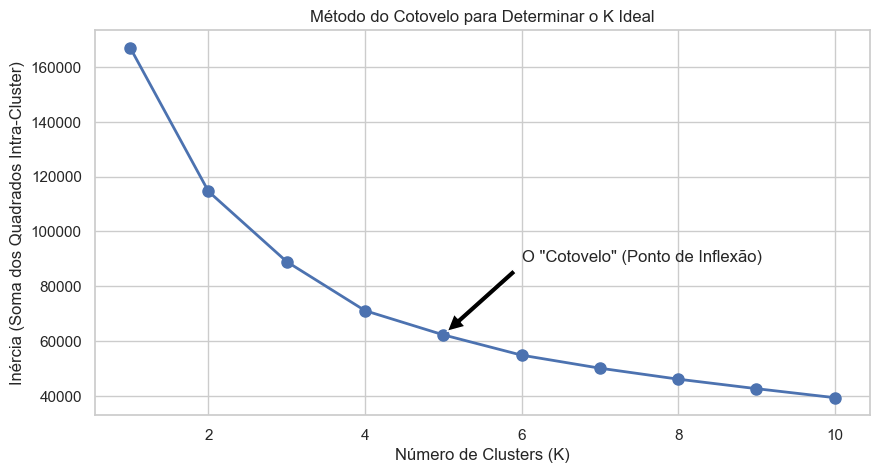

   Quantidade de Clusters (K)  Inércia (WCSSE)
0                           1    167100.000000
1                           2    114628.721541
2                           3     88978.988321
3                           4     71107.701466
4                           5     62273.206584
5                           6     54855.863884
6                           7     50104.370697
7                           8     46095.741837
8                           9     42623.772216
9                          10     39337.555238


In [84]:
 # Lista para armazenar as inércias

inercias = []

K = range(1, 11) # Testando de 1 a 10 clusters


# Rodando o K-Means para cada valor de K
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled) # Use os dados que você usou no seu modelo
    inercias.append(kmeans.inertia_)

# Criando a tabela de avaliação
tabela_cotovelo = pd.DataFrame({
    'Quantidade de Clusters (K)': K,
    'Inércia (WCSSE)': inercias
})

# Plotando o gráfico
plt.figure(figsize=(10, 5))
plt.plot(K, inercias, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Soma dos Quadrados Intra-Cluster)')
plt.title('Método do Cotovelo para Determinar o K Ideal')
plt.annotate('O "Cotovelo" (Ponto de Inflexão)', xy=(5, inercias[4]), xytext=(6, inercias[2]),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.grid(True)

plt.savefig(f"{REPORTS_DIRECTORY_PATH}/08_barplot_metodo_cotovelo.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Exibindo a tabela
print(tabela_cotovelo) 

In [85]:
df_aux

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,pib_per_capita,va_per_capita,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos,taxa_va_agroupecuaria,taxa_va_industria,taxa_va_servicos,taxa_va_addess
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,20251.418650,19268.823579,0.654188,0.263403,3.341386,0.048518,0.347422,0.066075,0.239517,0.298469
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,20749.572503,19675.487346,0.660397,0.254617,3.309973,0.051764,0.349469,0.056332,0.223244,0.319189
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,21538.395131,20318.772392,0.666811,0.245263,3.278136,0.056626,0.332462,0.052227,0.247509,0.311177
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,21607.103944,20327.914578,0.673262,0.236173,3.246722,0.059202,0.328109,0.029183,0.262849,0.320656
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,25089.845125,23545.098557,0.679690,0.241508,3.216017,0.061569,0.356680,0.036327,0.263455,0.281970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,81495.429074,71411.221068,0.768060,0.237064,501.706799,0.123740,0.003485,0.041022,0.440944,0.390810
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,83492.831767,73557.691986,0.757360,0.232210,508.794898,0.118994,0.003385,0.034524,0.442633,0.400465
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,85661.393759,76015.964283,0.746248,0.228344,516.371299,0.112599,0.004013,0.037444,0.446469,0.399474
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,90742.750230,80565.675754,0.736209,0.225023,523.412876,0.112153,0.003627,0.034551,0.457805,0.391864


In [32]:
# 4. Executando o K-Means final com 5 clusters
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 5. Adicionando o resultado de volta ao DataFrame original
# Usamos .loc para garantir que os clusters batam com os índices originais caso existam NaNs removidos
df_aux.loc[df_aux.index, 'cluster_original'] = clusters

# 6. Verificando o perfil médio de cada grupo
medias_por_cluster = df_aux.groupby('cluster_original')['pib_per_capita'].mean().sort_values()

mapeamento_ordenado = {cluster_antigo: i for i, cluster_antigo in enumerate(medias_por_cluster.index)}

df_aux.loc[df_aux.index,'cluster_hierarquico'] = df_aux['cluster_original'].map(mapeamento_ordenado)

medias_pib = df_aux.groupby('cluster_hierarquico')['pib_per_capita'].mean().reset_index()
print("PIB Per Capita Médio por Cluster:")
print(medias_pib)

PIB Per Capita Médio por Cluster:
   cluster_hierarquico  pib_per_capita
0                  0.0     9613.809330
1                  1.0    23761.684660
2                  2.0    27981.326096
3                  3.0    41617.388965
4                  4.0   179279.921091


In [33]:
df_aux

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos,taxa_va_agroupecuaria,taxa_va_industria,taxa_va_servicos,taxa_va_addess,cluster_original,cluster_hierarquico
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,0.654188,0.263403,3.341386,0.048518,0.347422,0.066075,0.239517,0.298469,1.0,2.0
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,0.660397,0.254617,3.309973,0.051764,0.349469,0.056332,0.223244,0.319189,1.0,2.0
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,0.666811,0.245263,3.278136,0.056626,0.332462,0.052227,0.247509,0.311177,1.0,2.0
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,0.673262,0.236173,3.246722,0.059202,0.328109,0.029183,0.262849,0.320656,1.0,2.0
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,0.679690,0.241508,3.216017,0.061569,0.356680,0.036327,0.263455,0.281970,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,0.768060,0.237064,501.706799,0.123740,0.003485,0.041022,0.440944,0.390810,3.0,1.0
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,0.757360,0.232210,508.794898,0.118994,0.003385,0.034524,0.442633,0.400465,3.0,1.0
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,0.746248,0.228344,516.371299,0.112599,0.004013,0.037444,0.446469,0.399474,3.0,1.0
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,0.736209,0.225023,523.412876,0.112153,0.003627,0.034551,0.457805,0.391864,3.0,1.0


In [34]:
df_2019 = df_aux[df_aux['ano'] == 2019]

#### Gráficos Comparativos

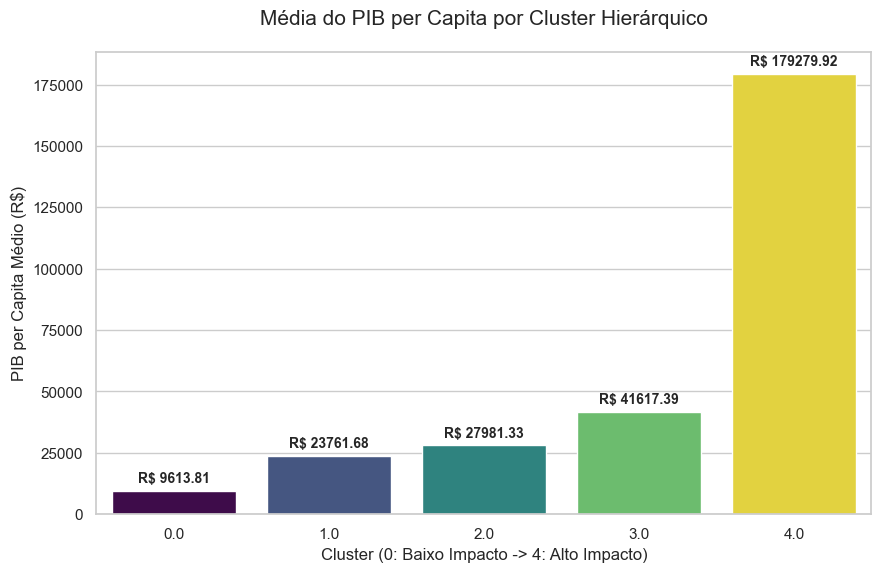

In [35]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Criando o Barplot
# O Seaborn calcula automaticamente a média do 'target' para cada 'cluster'
ax = sns.barplot(
    x='cluster_hierarquico', 
    y='pib_per_capita',
    hue='cluster_hierarquico',
    data=df_aux,
    errorbar=None,
    legend=False,
    palette='viridis',  # Gradiente de cor que reforça a ideia de escala
)

# Adicionando títulos e rótulos
plt.title('Média do PIB per Capita por Cluster Hierárquico', fontsize=15, pad=20)
plt.xlabel('Cluster (0: Baixo Impacto -> 4: Alto Impacto)', fontsize=12)
plt.ylabel('PIB per Capita Médio (R$)', fontsize=12)

# Adicionando os valores exatos em cima das barras para facilitar a leitura
for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.savefig(f"{REPORTS_DIRECTORY_PATH}/09_barplot_media_pib_per_capita_por_cluster_hierarquico.png", dpi=300, bbox_inches='tight')

plt.show()
plt.close()

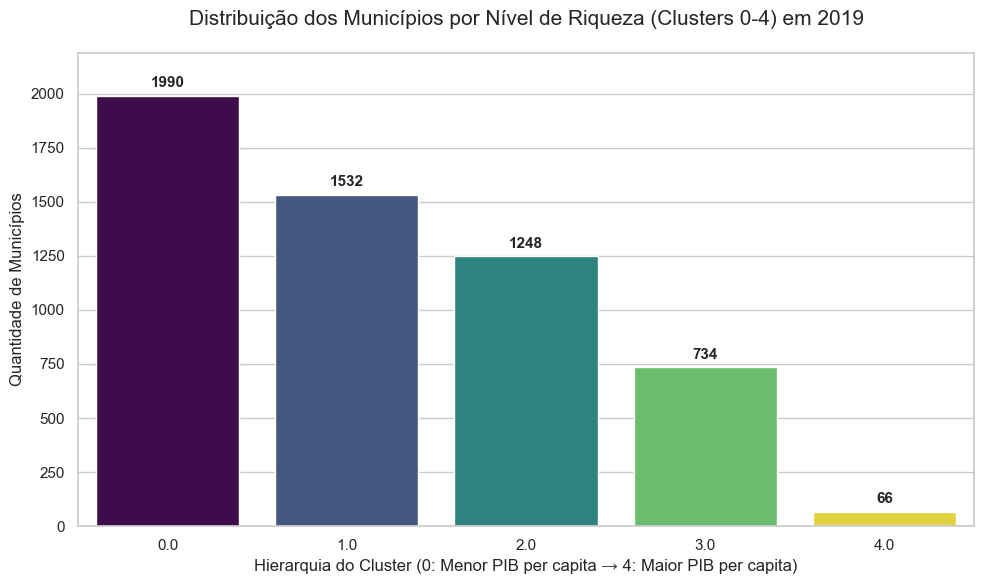

In [36]:
# 1. Configurar o estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Criar o gráfico de contagem (Countplot)
# Usando a coluna 'cluster_hierarquico' que criamos com a lógica de 0 a 4
ax = sns.countplot(
    data=df_2019, 
    x='cluster_hierarquico', 
    palette='viridis',
    hue='cluster_hierarquico', # Para evitar avisos de versões futuras do Seaborn
    legend=False
)

# 3. Adicionar os números exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11,
                fontweight='bold')

# 4. Customização de títulos e eixos
plt.title('Distribuição dos Municípios por Nível de Riqueza (Clusters 0-4) em 2019', fontsize=15, pad=20)
plt.xlabel('Hierarquia do Cluster (0: Menor PIB per capita → 4: Maior PIB per capita)', fontsize=12)
plt.ylabel('Quantidade de Municípios', fontsize=12)

# Ajustar os limites para o texto não cortar no topo
plt.ylim(0, df_2019['cluster_hierarquico'].value_counts().max() * 1.1)
plt.tight_layout()

plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '09_distribuicao_municipios_por_nivel_de_riqueza_colorido.png'), dpi=300, bbox_inches='tight')

plt.show()
plt.close()

In [37]:
df_2019

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos,taxa_va_agroupecuaria,taxa_va_industria,taxa_va_servicos,taxa_va_addess,cluster_original,cluster_hierarquico
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,0.673262,0.236173,3.246722,0.059202,0.328109,0.029183,0.262849,0.320656,1.0,2.0
8,1100023,2019,107863,Ariquemes,2579278000,284380000,2294898000,170831000,284066000,1136245000,...,0.660551,0.248241,24.369524,0.110256,0.066232,0.110134,0.440528,0.272850,3.0,1.0
13,1100031,2019,5312,Cabixi,139976000,5998000,133978000,61501000,3268000,25553000,...,0.719503,0.253953,4.041535,0.042850,0.439368,0.023347,0.182553,0.311882,1.0,2.0
18,1100049,2019,85359,Cacoal,2261930000,253987000,2007943000,193077000,178279000,1072272000,...,0.762146,0.259926,22.504350,0.112288,0.085359,0.078817,0.474052,0.249484,3.0,1.0
23,1100056,2019,16323,Cerejeiras,506494000,76665000,429829000,70992000,16155000,230264000,...,0.706365,0.228206,5.864627,0.151364,0.140164,0.031896,0.454623,0.221955,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27828,5222005,2019,13863,Vianópolis,489265000,37937000,451327000,174225000,29204000,176001000,...,0.802929,0.217702,14.529695,0.077539,0.356095,0.059690,0.359725,0.146949,1.0,2.0
27833,5222054,2019,8743,Vicentinópolis,326519000,26229000,300290000,100352000,55854000,97434000,...,0.721377,0.215715,11.914788,0.080329,0.307339,0.171059,0.298402,0.142871,1.0,2.0
27838,5222203,2019,6171,Vila Boa,112209000,8562000,103646000,24111000,13855000,33693000,...,0.450332,0.211473,5.862665,0.076304,0.214876,0.123475,0.300270,0.285075,1.0,2.0
27843,5222302,2019,5821,Vila Propício,207994000,8020000,199974000,104542000,29303000,35883000,...,0.678406,0.224016,2.668234,0.038559,0.502620,0.140884,0.172519,0.145418,1.0,2.0


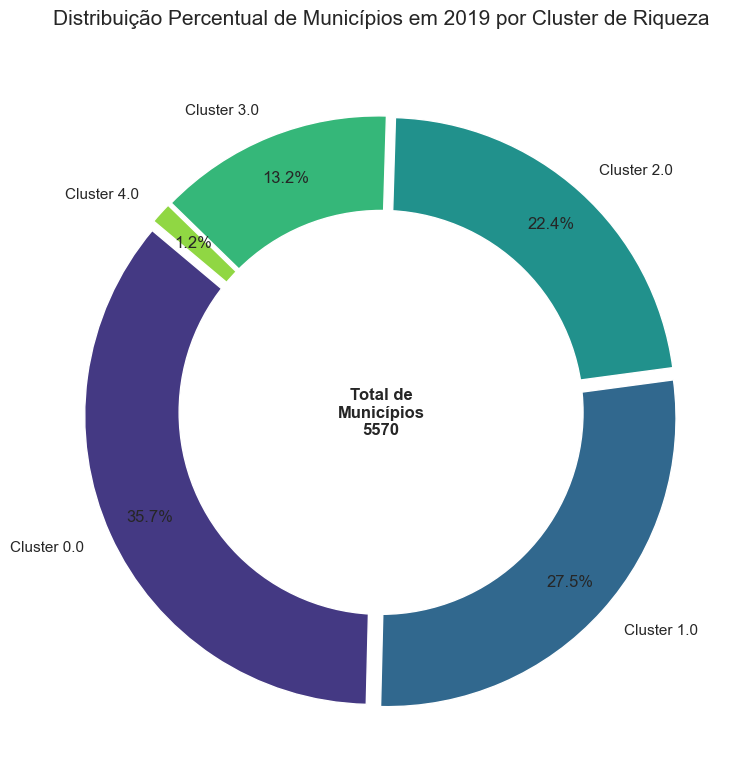

In [38]:
# 1. Preparar os dados: Contar quantos municípios existem em cada cluster
contagem_municipios = df_2019['cluster_hierarquico'].value_counts().sort_index()
total_municipios = contagem_municipios.sum()

# 2. Configurar o estilo e cores
sns.set_theme(style="white")
plt.figure(figsize=(10, 8))
# Usando a paleta viridis para manter a consistência com o seu gráfico anterior
cores = sns.color_palette('viridis', len(contagem_municipios))
labels = [f'Cluster {i}' for i in contagem_municipios.index]

# 3. Criar o gráfico de pizza (Circle Plot)
plt.pie(
    contagem_municipios, 
    labels=labels, 
    autopct='%1.1f%%',   # Exibe a porcentagem de municípios
    startangle=140, 
    colors=cores,
    pctdistance=0.85,
    explode=[0.03] * len(contagem_municipios) # Pequeno destaque entre as fatias
)

# 4. Transformar em Donut (Círculo central branco)
centro = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro)

# 5. Adicionar o número total no centro para dar contexto
plt.text(0, 0, f'Total de\nMunicípios\n{total_municipios}', 
         ha='center', va='center', fontsize=12, fontweight='bold')

# 6. Título
plt.title('Distribuição Percentual de Municípios em 2019 por Cluster de Riqueza', fontsize=15, pad=20)

plt.tight_layout()

# 7. Salvar
plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '10_distribuicao_municipios_pizza_porcentagem.png'), dpi=300, bbox_inches='tight')

plt.show()
plt.close()

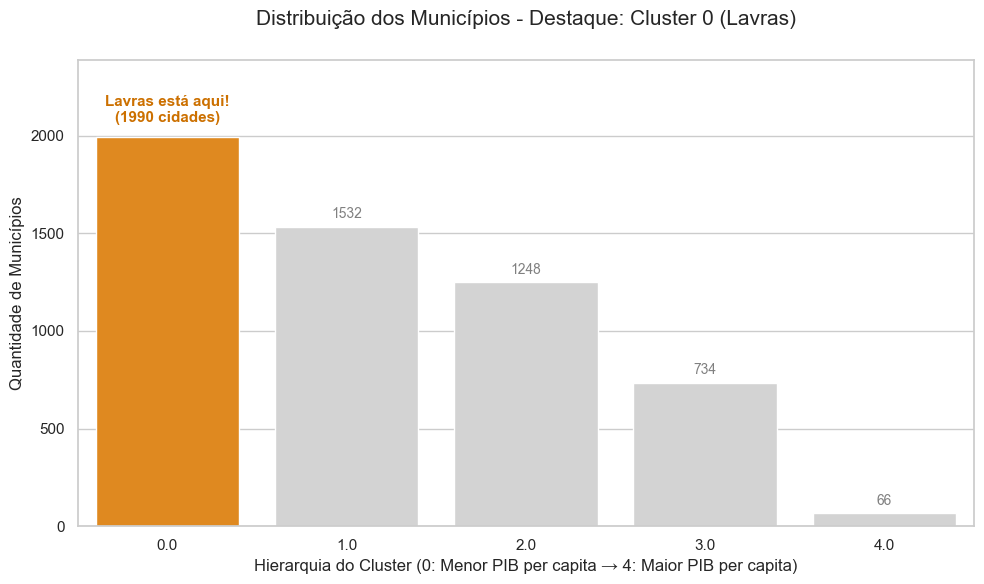

In [39]:
# 1. Identificar o cluster de Lavras (supondo que a coluna de nome seja 'nome_municipio')
cluster_lavras = df_2019[df_2019['id_municipio_nome'].str.contains('Lavras', case=False)]['cluster_hierarquico'].iloc[0]

# 2. Configurar o estilo e as cores
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Criamos uma paleta customizada: Cinza para todos, Destaque para o cluster de Lavras
cores = ['#D3D3D3' if c != cluster_lavras else '#FF8C00' for c in sorted(df_2019['cluster_hierarquico'].unique())]

# 3. Criar o barplot de contagem
ax = sns.countplot(
    data=df_2019, 
    x='cluster_hierarquico', 
    palette=cores,
    hue='cluster_hierarquico',
    legend=False
)

# 4. Adicionar anotações de texto
for p in ax.patches:
    altura = p.get_height()
    # Se for a barra de Lavras, adicionamos um texto extra
    if p.get_x() + p.get_width()/2 == cluster_lavras:
        ax.annotate(f'Lavras está aqui!\n({int(altura)} cidades)', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', xytext=(0, 20), 
                    textcoords='offset points', fontsize=11, fontweight='bold', color='#CC7000')
    else:
        ax.annotate(f'{int(altura)}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', xytext=(0, 9), 
                    textcoords='offset points', fontsize=10, color='gray')

# 5. Ajustes finais
plt.title(f'Distribuição dos Municípios - Destaque: Cluster {int(cluster_lavras)} (Lavras)', fontsize=15, pad=25)
plt.xlabel('Hierarquia do Cluster (0: Menor PIB per capita → 4: Maior PIB per capita)', fontsize=12)
plt.ylabel('Quantidade de Municípios', fontsize=12)
plt.ylim(0, df_2019['cluster_hierarquico'].value_counts().max() * 1.2) # Espaço para o texto
plt.tight_layout()

plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '10_distribuicao_municipios_por_nivel_de_riqueza_lavras.png'), dpi=300, bbox_inches='tight')

plt.show()
plt.close()

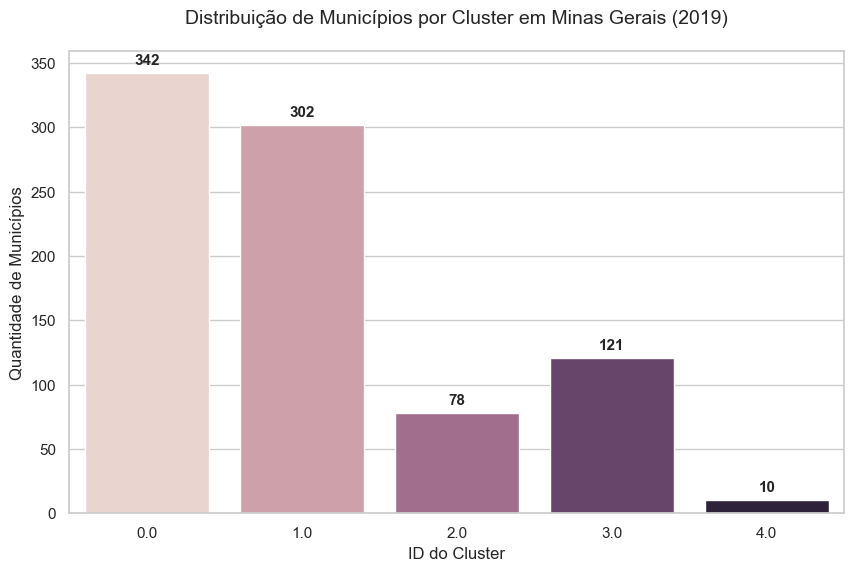

In [40]:
df_mg_2019 = df_aux[df_aux['NM_UF_SIGLA'] == 'MG']
df_mg_2019 = df_mg_2019[df_mg_2019['ano'] == 2019]
# 1. Configuração estética do Seaborn
sns.set_theme(style="whitegrid", palette="viridis")
plt.figure(figsize=(10, 6))

# 2. Criar o gráfico de contagem (Countplot)
# O Seaborn faz a contagem automaticamente para você, não precisa de .value_counts()
ax = sns.countplot(
    data=df_mg_2019, 
    x='cluster_hierarquico',
    hue='cluster_hierarquico', # Para evitar avisos de versões futuras
    legend=False
)

# 3. Adicionar os números em cima das barras (O "pulo do gato")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# 4. Títulos e Eixos
plt.title('Distribuição de Municípios por Cluster em Minas Gerais (2019)', fontsize=14, pad=20)
plt.xlabel('ID do Cluster', fontsize=12)
plt.ylabel('Quantidade de Municípios', fontsize=12)

# 5. Salvando como imagem estática (PNG/PDF) para o seu diretório de relatórios
plt.savefig(f"{REPORTS_DIRECTORY_PATH}/11_distribuicao_clusters_minas_gerais.png", dpi=300, bbox_inches='tight')

plt.show()

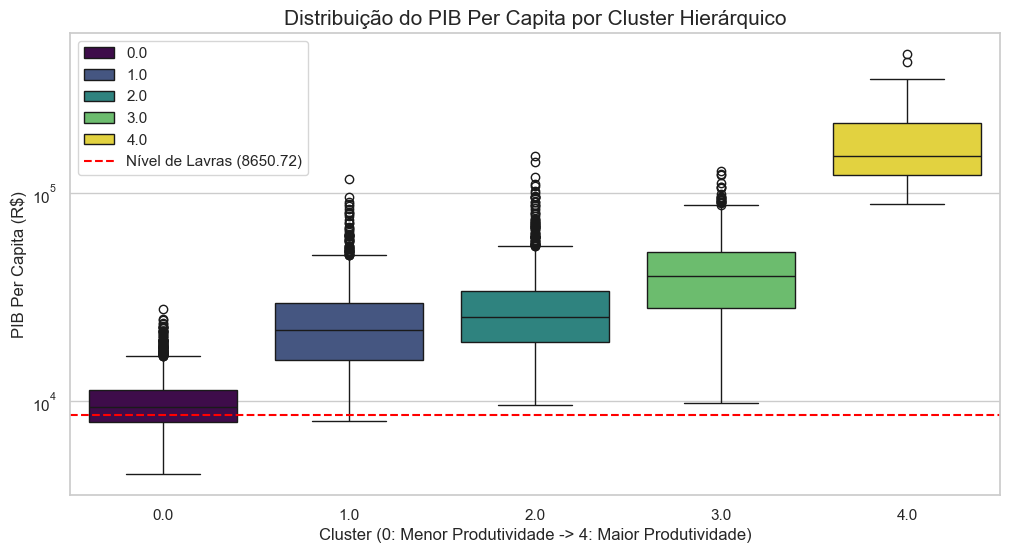

In [41]:

# --- Passo 2: Gerar o Boxplot com Seaborn ---
plt.figure(figsize=(12, 6))

# Criando o boxplot
ax = sns.boxplot(x='cluster_hierarquico', 
            y='pib_per_capita', 
            data=df_2019, 
            palette='viridis',
            hue='cluster_hierarquico')

# Adicionando uma linha vermelha para destacar onde Lavras está
# (Substitua o valor abaixo pelo PIB per capita real de Lavras que você tem)
pib_lavras = df_2019[df_2019['nome_municipio'].str.contains('Lavras')]['pib_per_capita'].iloc[0]
plt.axhline(pib_lavras, color='red', linestyle='--', label=f'Nível de Lavras ({pib_lavras:.2f})')

ax.set_yscale("log")
# Configurações do gráfico
plt.title('Distribuição do PIB Per Capita por Cluster Hierárquico', fontsize=15)
plt.xlabel('Cluster (0: Menor Produtividade -> 4: Maior Produtividade)', fontsize=12)
plt.ylabel('PIB Per Capita (R$)', fontsize=12)
plt.legend()

plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '12_boxplot_distribuicao_pib_per_capita_por_cluster_hierarquico.png'), dpi=300, bbox_inches='tight')

plt.show()
plt.close()

#### Salvando Modelo e Dados

In [42]:
df_aux.to_csv(f"{FEATURES_DIRECTORY_PATH}/informacoes_cada_municipio_2019_clusterizado.csv", index=False)

In [43]:
score = silhouette_score(X_scaled, df_aux['cluster_hierarquico'])
print(f"{score}")

0.34950529729153873


In [44]:
modelo_atual = {
    'silhouette_score' : score,
    'n_clusters' : n_clusters,
    'modelo' : kmeans,
    'scaler' : scaler,
    'features' : features,
    'data_treinado' : datetime.now().strftime('%Y-%m-%d %H:%M')
}
nome_arquivo = "clusterizacao_k_means_municipios_2019.pkl"
with open(f"{MODELS_DIRECTORY_PATH}/{nome_arquivo}", 'wb') as arquivo:
    pickle.dump(modelo_atual, arquivo)

print(f"Modelo salvo com sucesso em: {nome_arquivo}")

Modelo salvo com sucesso em: clusterizacao_k_means_municipios_2019.pkl


## Modelo de Machine Learning - Random Forest

In [45]:
df_aux = pd.read_csv(f"{FEATURES_DIRECTORY_PATH}/informacoes_cada_municipio_2019_clusterizado.csv")

In [46]:
df_aux

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos,taxa_va_agroupecuaria,taxa_va_industria,taxa_va_servicos,taxa_va_addess,cluster_original,cluster_hierarquico
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,0.654188,0.263403,3.341386,0.048518,0.347422,0.066075,0.239517,0.298469,1.0,2.0
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,0.660397,0.254617,3.309973,0.051764,0.349469,0.056332,0.223244,0.319189,1.0,2.0
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,0.666811,0.245263,3.278136,0.056626,0.332462,0.052227,0.247509,0.311177,1.0,2.0
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,0.673262,0.236173,3.246722,0.059202,0.328109,0.029183,0.262849,0.320656,1.0,2.0
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,0.679690,0.241508,3.216017,0.061569,0.356680,0.036327,0.263455,0.281970,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,0.768060,0.237064,501.706799,0.123740,0.003485,0.041022,0.440944,0.390810,3.0,1.0
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,0.757360,0.232210,508.794898,0.118994,0.003385,0.034524,0.442633,0.400465,3.0,1.0
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,0.746248,0.228344,516.371299,0.112599,0.004013,0.037444,0.446469,0.399474,3.0,1.0
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,0.736209,0.225023,523.412876,0.112153,0.003627,0.034551,0.457805,0.391864,3.0,1.0


### Pré-Processamento

In [47]:
# 1. Seleção
features = ['taxa_va_agroupecuaria', 'taxa_va_servicos', 'taxa_va_industria', 'taxa_va_addess', 'participacao_impostos', 'cluster_hierarquico']
target = 'pib_per_capita'

# 2. Separação Manual 
# Treino utilizara dados de 2016 a 2019
X = df_aux[(df_aux['ano'] >= 2016) & (df_aux['ano'] <= 2019)]
X_train = X[features] # Variavel de Treinamento do modelo
y_train = X[target]   # Variavel de

# Teste utilizara dados de 2020
y = df_aux[df_aux['ano'] == 2020]
X_test = y[features] # Variavel de Teste do Modelo
y_test = y[target]   # 


In [48]:
X_train

,taxa_va_agroupecuaria,taxa_va_servicos,taxa_va_industria,taxa_va_addess,participacao_impostos,cluster_hierarquico
0,0.347422,0.239517,0.066075,0.298469,0.048518,2.0
1,0.349469,0.223244,0.056332,0.319189,0.051764,2.0
2,0.332462,0.247509,0.052227,0.311177,0.056626,2.0
3,0.328109,0.262849,0.029183,0.320656,0.059202,2.0
5,0.066413,0.402663,0.162194,0.269634,0.099096,1.0
...,...,...,...,...,...,...
27843,0.502620,0.172519,0.140884,0.145418,0.038559,2.0
27845,0.003485,0.440944,0.041022,0.390810,0.123740,1.0
27846,0.003385,0.442633,0.034524,0.400465,0.118994,1.0
27847,0.004013,0.446469,0.037444,0.399474,0.112599,1.0


### Treinamento

In [49]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Predição

In [50]:
y_pred = rf_model.predict(X_test)

### Avalição da Modelo

In [51]:
r2 = r2_score(y_test, y_pred)
mea = mean_absolute_error(y_test, y_pred)

print(f"RF - R² Score: {r2:.4f}")
print(f"RF - MAE: {mea:.2f}")

RF - R² Score: 0.8991
RF - MAE: 4383.76


### Importância das Variáveis

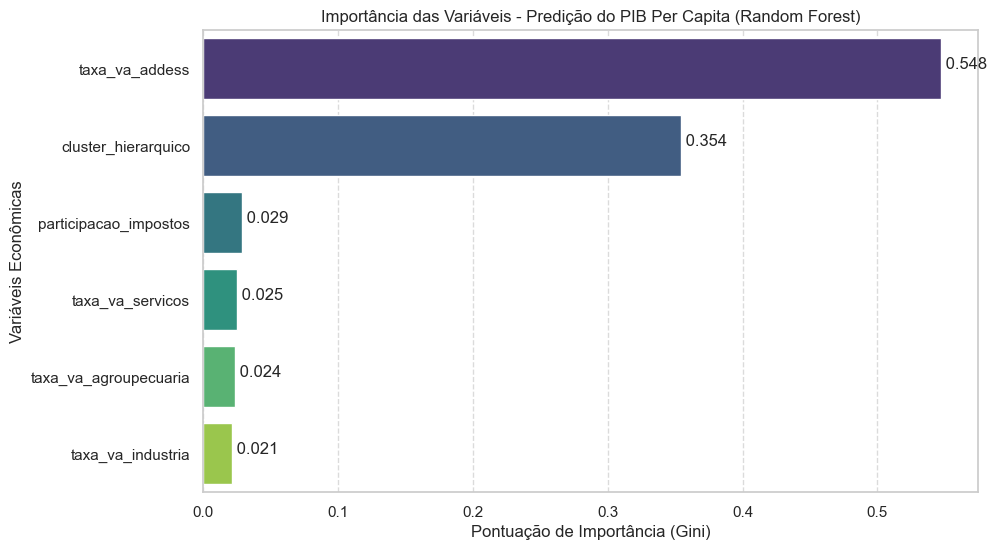

In [52]:
# 1. Extrair as importâncias do modelo treinado
importancias = rf_model.feature_importances_

# 2. Criar um DataFrame para facilitar a plotagem
df_importancia = pd.DataFrame({
    'Variável': features,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# 3. Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=df_importancia, palette='viridis', hue='Variável')

plt.title('Importância das Variáveis - Predição do PIB Per Capita (Random Forest)')
plt.xlabel('Pontuação de Importância (Gini)')
plt.ylabel('Variáveis Econômicas')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adiciona os valores nas barras para facilitar a leitura
for index, value in enumerate(df_importancia['Importância']):
    plt.text(value, index, f' {value:.3f}')

plt.savefig(f"{REPORTS_DIRECTORY_PATH}/13_barplot_importancia_das_variaveis_predicao_do_pib_per_capita.png", dpi=300, bbox_inches='tight')

plt.show()
plt.close()

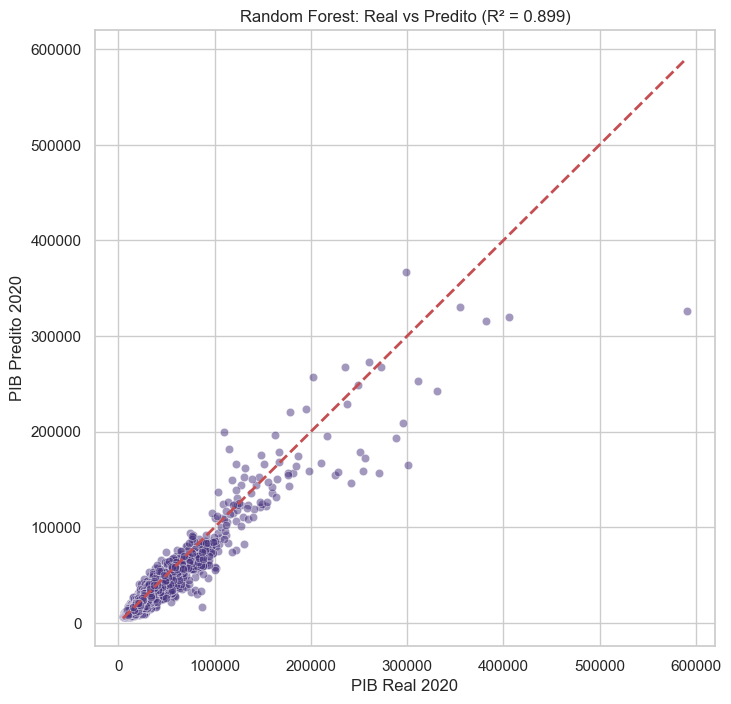

In [53]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Linha de perfeição

plt.title(f'Random Forest: Real vs Predito (R² = {r2:.3f})')
plt.xlabel('PIB Real 2020')
plt.ylabel('PIB Predito 2020')

plt.savefig(f"{REPORTS_DIRECTORY_PATH}/14_scatterplot_comparacao_predito_real_random_forest_pib_per_capita.png", dpi=300, bbox_inches='tight')

plt.show()
plt.close()

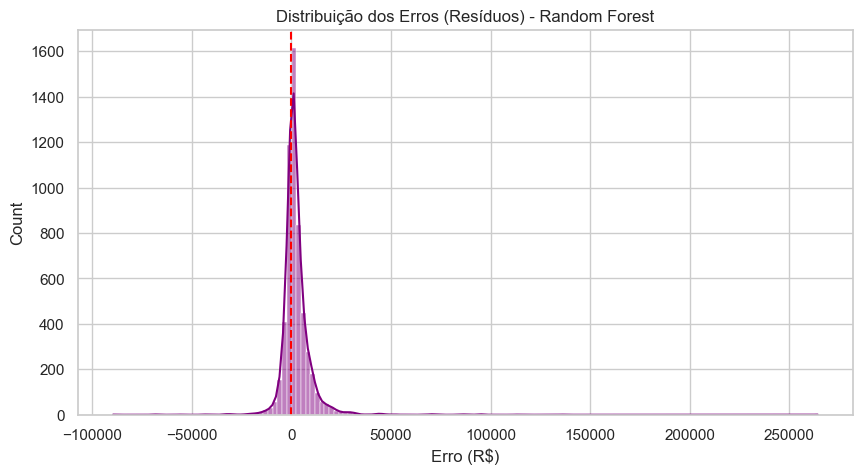

In [54]:
residuos = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribuição dos Erros (Resíduos) - Random Forest')
plt.xlabel('Erro (R$)')

plt.savefig(f"{REPORTS_DIRECTORY_PATH}/15_histplot_distribuicao_dos_erros_random_forest_pib_per_capita.png", dpi=300, bbox_inches='tight')

plt.show()
plt.close()

### Salvar Dados e Modelo

In [55]:
# Criamos um dicionário para empacotar tudo que é necessário para a predição
modelo_atual = {
    'model': rf_model,
    'target' : target,
    'features': features,
    'metrics' : {
        'r2' : r2,
        'mea' : mea
    },
    'data_treinado' : datetime.now().strftime('%Y-%m-%d %H:%M')
}

nome_arquivo = "ia_random_forest_regressao.joblib"
# Salvando em disco
# compress=3: Reduz o tamanho sem gastar muito tempo/CPU
joblib.dump(modelo_atual, f"{MODELS_DIRECTORY_PATH}/{nome_arquivo}", compress=3)

print(f"Modelo salvo com sucesso em: {nome_arquivo}")

Modelo salvo com sucesso em: ia_random_forest_regressao.joblib


## Modelo de Machine Learning - Regressão Linear

### Target como PIB per Capita

#### Pré-Processamento

In [56]:
# 1. Seleção
features = ['taxa_va_agroupecuaria', 'taxa_va_servicos', 'taxa_va_industria', 'taxa_va_addess', 'participacao_impostos', 'cluster_hierarquico']
target = 'pib_per_capita'

# 2. Separação Manual 
# Treino utilizara dados de 2016 a 2019
X = df_aux[(df_aux['ano'] >= 2016) & (df_aux['ano'] <= 2019)]
X_train = X[features] # Variavel de Treinamento do modelo
y_train = X[target]   # Variavel de

# Teste utilizara dados de 2020
y = df_aux[df_aux['ano'] == 2020]
X_test = y[features] # Variavel de Teste do Modelo
y_test = y[target]   # 

# 3. Scaler (Ajusta no treino, aplica no teste)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Treinamento

In [57]:
# 4. Regressão
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Predição

In [58]:
y_pred = model.predict(X_test_scaled)

In [59]:
y_pred

array([23859.41053179, 26001.05103975, 26656.59826155, ...,
       31541.18225203, 38021.2124315 , 10401.28077556], shape=(5570,))

#### Avaliação do Modelo

In [60]:
# Avaliação do modelo
r2 = r2_score(y_test, y_pred)
mea = mean_absolute_error(y_test, y_pred)
print(f"R² do modelo: {r2:.2f}")
print(f"Erro Médio Absoluto do modelo: {mea:.2f}")

R² do modelo: 0.43
Erro Médio Absoluto do modelo: 9095.34


#### Gráficos Comparativos

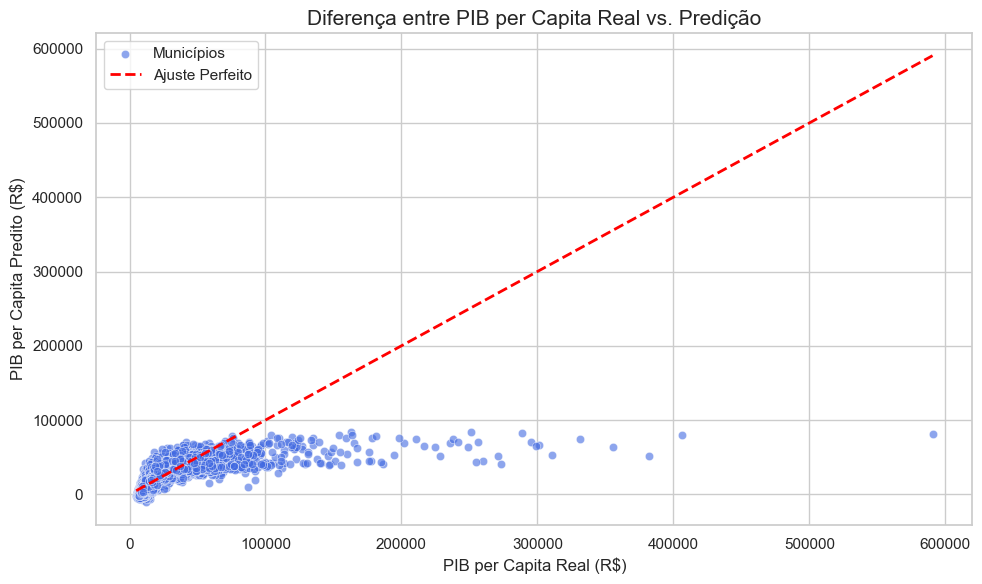

In [61]:
# 1. Definir o estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Plotar os valores Reais vs Preditos
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='royalblue', label='Municípios')

# 3. Criar a linha de "Perfeição" (onde Real == Predito)
limites = [y_test.min(), y_test.max()]
plt.plot(limites, limites, color='red', linestyle='--', lw=2, label='Ajuste Perfeito')

# 4. Detalhes do gráfico
plt.title('Diferença entre PIB per Capita Real vs. Predição', fontsize=15)
plt.xlabel('PIB per Capita Real (R$)', fontsize=12)
plt.ylabel('PIB per Capita Predito (R$)', fontsize=12)
plt.legend()
plt.tight_layout()


plt.savefig(f"{REPORTS_DIRECTORY_PATH}/16_scatterplot_diferenca_entre_pib_per_capita_real_vs_predicao.png", dpi=300, bbox_inches='tight')

plt.show()
plt.close()

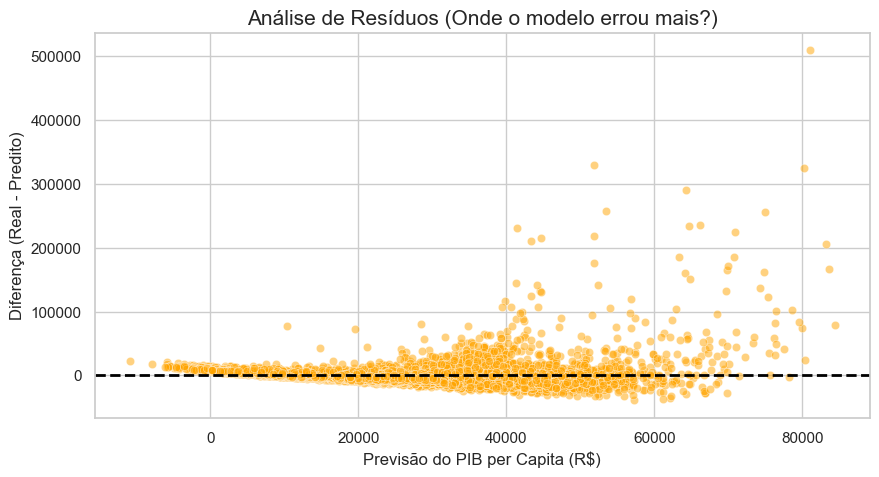

In [62]:
# Calculando a diferença (Resíduo)
erros = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.axhline(y=0, color='black', linestyle='--', lw=2) # Linha de erro zero
sns.scatterplot(x=y_pred, y=erros, alpha=0.5, color='orange')

plt.title('Análise de Resíduos (Onde o modelo errou mais?)', fontsize=15)
plt.xlabel('Previsão do PIB per Capita (R$)', fontsize=12)
plt.ylabel('Diferença (Real - Predito)', fontsize=12)

plt.savefig(f"{REPORTS_DIRECTORY_PATH}/17_scatterplot_analise_de_residuos_pib_per_capita_real_predicao_regressao_linear.png", dpi=300, bbox_inches='tight')

plt.show()
plt.close()

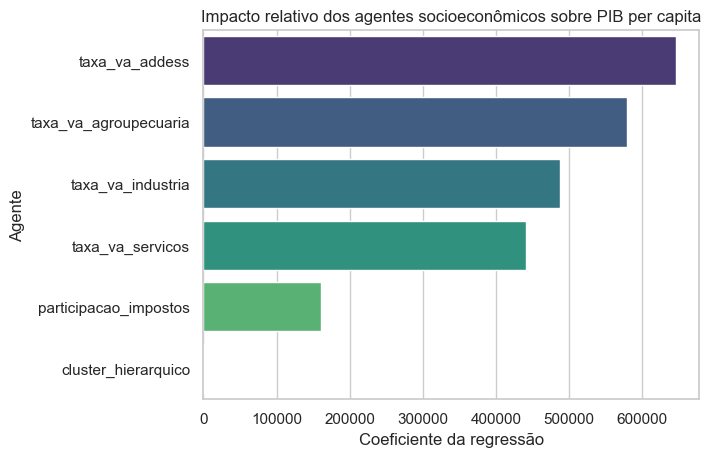

In [63]:
# Criar um DataFrame com os coeficientes do modelo para cada variável (agente)
coef_df = pd.DataFrame({
    'agente': features,       # Nomes das variáveis independentes
    'impacto': model.coef_    # Coeficientes da regressão linear
})

# Ordenar o DataFrame pelos coeficientes em ordem decrescente
coef_df = coef_df.sort_values('impacto', ascending=False)

# Criar um gráfico de barras mostrando o impacto relativo de cada agente
sns.barplot(data=coef_df, x='impacto', y='agente', palette='viridis', hue='agente')
plt.title('Impacto relativo dos agentes socioeconômicos sobre PIB per capita')  # Título do gráfico
plt.xlabel('Coeficiente da regressão')  # Label do eixo X
plt.ylabel('Agente')                     # Label do eixo Y

# Salvar a figura em alta resolução
plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '18_impacto_rel_agentes_socioeconomicos_pib_per_capita.png'), dpi=300, bbox_inches='tight')

plt.show()   # Exibir o gráfico
plt.close()  # Fechar a figura para liberar memória


#### Salvando o Modelo

In [64]:
modelo_atual = {
    'modelo' : model,
    'scaler' : scaler,
    'features' : features,
    'target' : target,
    'metrics' : {
        'r2' : r2,
        'mea' : mea,
    },
    'data_treinado' : datetime.now().strftime('%Y-%m-%d %H:%M')
}
nome_arquivo = "regressao_linear_prever_pib_per_capita.pkl"
with open(f"{MODELS_DIRECTORY_PATH}/{nome_arquivo}", 'wb') as arquivo:
    pickle.dump(modelo_atual, arquivo)

print(f"Modelo salvo com sucesso em: {nome_arquivo}")

Modelo salvo com sucesso em: regressao_linear_prever_pib_per_capita.pkl


## Uso do SHAP para a interpretação dos modelos

In [65]:
df_aux.to_csv(f"{FEATURES_DIRECTORY_PATH}/informacoes_municipios_com_clusters.csv", index=False)

### Aplicação no Random Forest

In [66]:
dicionario_modelo = joblib.load(f"{MODELS_DIRECTORY_PATH}/ia_random_forest_regressao.joblib")
    
modelo_rf = dicionario_modelo.get("model")
features = dicionario_modelo.get("features")
target = dicionario_modelo.get("target")

# Teste utilizara dados de 2020
y = df_aux[df_aux['ano'] == 2020]
X_test = y[features] # Variavel de Teste do Modelo
y_test = y[target]   # 

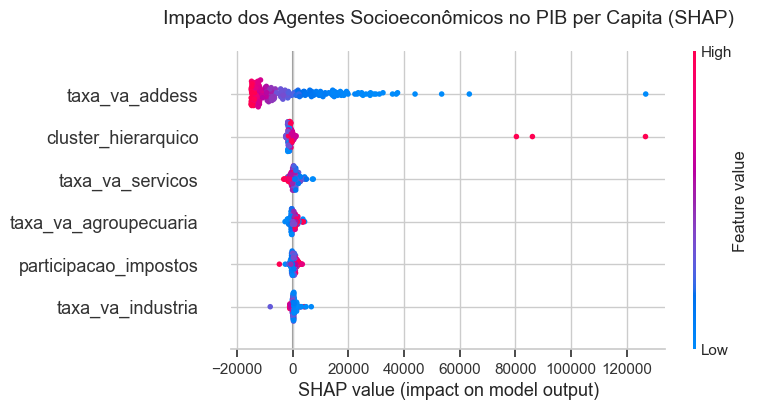

In [67]:
# 1. Criar o explicador
explainer = shap.TreeExplainer(modelo_rf)

X_test_amostra = X_test.sample(n=200, random_state=42)

if os.path.exists(f"{ROOT_DIR}/shap_values_backup.npy"):
    shap_values = np.load(f"{ROOT_DIR}/shap_values_backup.npy")
else:
    # 2. Calcular os valores SHAP
    shap_values = explainer.shap_values(X_test_amostra, check_additivity=False)
    np.save(f"{ROOT_DIR}/shap_values_backup.npy", shap_values)


# 1. Setup the plot (Optional: set figure size before calling SHAP)
plt.figure(figsize=(10, 6))

# 2. Generate the SHAP plot 
# CRITICAL: Set show=False
shap.summary_plot(shap_values, X_test_amostra, show=False)

# 3. Add your title AFTER calling the plot (otherwise SHAP might overwrite it)
plt.title("Impacto dos Agentes Socioeconômicos no PIB per Capita (SHAP)", fontsize=14, pad=20)

# 4. Save the file
save_path = os.path.join(REPORTS_DIRECTORY_PATH, '19_SHAP_impacto_agentes_socioeconomicos_pib_per_capita.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 5. Now show it (if you are in a notebook)
plt.show()

## Gráficos Interativos

In [68]:
df_aux

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos,taxa_va_agroupecuaria,taxa_va_industria,taxa_va_servicos,taxa_va_addess,cluster_original,cluster_hierarquico
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,0.654188,0.263403,3.341386,0.048518,0.347422,0.066075,0.239517,0.298469,1.0,2.0
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,0.660397,0.254617,3.309973,0.051764,0.349469,0.056332,0.223244,0.319189,1.0,2.0
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,0.666811,0.245263,3.278136,0.056626,0.332462,0.052227,0.247509,0.311177,1.0,2.0
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,0.673262,0.236173,3.246722,0.059202,0.328109,0.029183,0.262849,0.320656,1.0,2.0
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,0.679690,0.241508,3.216017,0.061569,0.356680,0.036327,0.263455,0.281970,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,0.768060,0.237064,501.706799,0.123740,0.003485,0.041022,0.440944,0.390810,3.0,1.0
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,0.757360,0.232210,508.794898,0.118994,0.003385,0.034524,0.442633,0.400465,3.0,1.0
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,0.746248,0.228344,516.371299,0.112599,0.004013,0.037444,0.446469,0.399474,3.0,1.0
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,0.736209,0.225023,523.412876,0.112153,0.003627,0.034551,0.457805,0.391864,3.0,1.0


In [69]:
df_aux

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos,taxa_va_agroupecuaria,taxa_va_industria,taxa_va_servicos,taxa_va_addess,cluster_original,cluster_hierarquico
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,0.654188,0.263403,3.341386,0.048518,0.347422,0.066075,0.239517,0.298469,1.0,2.0
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,0.660397,0.254617,3.309973,0.051764,0.349469,0.056332,0.223244,0.319189,1.0,2.0
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,0.666811,0.245263,3.278136,0.056626,0.332462,0.052227,0.247509,0.311177,1.0,2.0
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,0.673262,0.236173,3.246722,0.059202,0.328109,0.029183,0.262849,0.320656,1.0,2.0
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,0.679690,0.241508,3.216017,0.061569,0.356680,0.036327,0.263455,0.281970,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,0.768060,0.237064,501.706799,0.123740,0.003485,0.041022,0.440944,0.390810,3.0,1.0
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,0.757360,0.232210,508.794898,0.118994,0.003385,0.034524,0.442633,0.400465,3.0,1.0
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,0.746248,0.228344,516.371299,0.112599,0.004013,0.037444,0.446469,0.399474,3.0,1.0
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,0.736209,0.225023,523.412876,0.112153,0.003627,0.034551,0.457805,0.391864,3.0,1.0


### Scatter 3D Mapa de Valor: Indústria vs Serviços no PIB

In [70]:
fig = px.scatter_3d(df_aux, 
                    x='taxa_va_industria', 
                    y='taxa_va_servicos', 
                    z='pib_per_capita',
                    color='cluster_hierarquico', 
                    size='pib_per_capita', # Cidades mais ricas ficam maiores
                    opacity=0.7,
                    hover_name='nome_municipio',
                    title='Mapa de Valor: Indústria vs Serviços no PIB',
                    color_discrete_sequence=px.colors.qualitative.Bold) # Cores vibrantes

fig.update_layout(scene = dict(
                    xaxis_title='V.A. Indústria',
                    yaxis_title='V.A. Serviços',
                    zaxis_title='PIB Per Capita'))

fig.write_html(f"{INTERACTIVE_REPORTS_PATH}/01_industria_vs_servicos_no_pib.html", 
                  include_plotlyjs='cdn', # Carrega a biblioteca via web (deixa o arquivo leve)
                  full_html=True)
fig.show()

### Barplot - Hierarquia de Impacto: Quais agentes explicam o PIB?

In [71]:
# 1. Calcular a importância média (tirando o valor absoluto)
# Se shap_values for uma lista (classificação), use shap_values[0]
avg_shap = np.abs(shap_values).mean(axis=0)

# 2. Criar DataFrame para o Plotly
importance_df = pd.DataFrame({
    'Agente Socioeconômico': X_test_amostra.columns,
    'Impacto Médio (SHAP)': avg_shap
})

# 3. Ordenar para o gráfico ficar em escada
importance_df = importance_df.sort_values(by='Impacto Médio (SHAP)', ascending=True)

fig = px.bar(importance_df, 
             x='Impacto Médio (SHAP)', 
             y='Agente Socioeconômico',
             orientation='h',
             color='Impacto Médio (SHAP)',
             color_continuous_scale='Sunsetdark',
             title='Hierarquia de Impacto: Quais agentes explicam o PIB?')

# fig.update_layout(yaxis={'categoryorder':'total ascending'})

fig.write_html(f"{INTERACTIVE_REPORTS_PATH}/02_hierarquia_de_impacto_agentes_explicam_PIB.html", 
                  include_plotlyjs='cdn', # Carrega a biblioteca via web (deixa o arquivo leve)
                  full_html=True)
fig.show()

### Scatter Mapbox - Mapa de Minas Gerais Por Cluster

In [72]:
df_aux[df_aux['id_municipio_nome'] == "Vitória"]

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos,taxa_va_agroupecuaria,taxa_va_industria,taxa_va_servicos,taxa_va_addess,cluster_original,cluster_hierarquico
15870,3205309,2016,350568,Vitória,21721213000,5105871000,16615342000,14438000,3225623000,11631180000,...,0.751557,0.272184,3609.526065,0.235064,0.000665,0.148501,0.535476,0.080295,3.0,1.0
15871,3205309,2017,354373,Vitória,20252080000,4918877000,15333202000,18092000,1994793000,11531592000,...,0.743488,0.271400,3648.703191,0.242883,0.000893,0.098498,0.569403,0.088323,3.0,1.0
15872,3205309,2018,358267,Vitória,25518127000,5698544000,19819583000,16542000,6166051000,11757460000,...,0.735407,0.260445,3688.796680,0.223314,0.000648,0.241634,0.460749,0.073655,4.0,3.0
15873,3205309,2019,362097,Vitória,23656637000,6226056000,17430581000,16858000,1598591000,13814712000,...,0.727628,0.257699,3728.231212,0.263184,0.000713,0.067575,0.583968,0.084561,3.0,1.0
15874,3205309,2020,365855,Vitória,25517575000,5721901000,19795673000,17610000,5199635000,12663748000,...,0.720154,0.248000,3766.924415,0.224234,0.000690,0.203767,0.496276,0.075034,4.0,3.0


In [73]:
df_aux

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos,taxa_va_agroupecuaria,taxa_va_industria,taxa_va_servicos,taxa_va_addess,cluster_original,cluster_hierarquico
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,0.654188,0.263403,3.341386,0.048518,0.347422,0.066075,0.239517,0.298469,1.0,2.0
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,0.660397,0.254617,3.309973,0.051764,0.349469,0.056332,0.223244,0.319189,1.0,2.0
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,0.666811,0.245263,3.278136,0.056626,0.332462,0.052227,0.247509,0.311177,1.0,2.0
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,0.673262,0.236173,3.246722,0.059202,0.328109,0.029183,0.262849,0.320656,1.0,2.0
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,0.679690,0.241508,3.216017,0.061569,0.356680,0.036327,0.263455,0.281970,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,0.768060,0.237064,501.706799,0.123740,0.003485,0.041022,0.440944,0.390810,3.0,1.0
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,0.757360,0.232210,508.794898,0.118994,0.003385,0.034524,0.442633,0.400465,3.0,1.0
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,0.746248,0.228344,516.371299,0.112599,0.004013,0.037444,0.446469,0.399474,3.0,1.0
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,0.736209,0.225023,523.412876,0.112153,0.003627,0.034551,0.457805,0.391864,3.0,1.0


In [74]:
# 1. Preparação dos Dados (Usando o ano de 2020)
# Filtramos primeiro para garantir que a análise seja do recorte temporal mais recente
df_2020 = df_aux[df_aux['ano'] == 2020].copy()

# 2. Identificação de Lavras e dos Clusters
# Localizamos o índice ou a linha de Lavras para o destaque
df_lavras = df_2020[df_2020['id_municipio'] == 3138203]

clusters = sorted(df_2020['cluster_hierarquico'].unique())
colors = px.colors.qualitative.Plotly  # Paleta de cores padrão

# 3. Inicialização da Figura
fig = go.Figure()

# 4. Adição dos Traces (Camadas) por Cluster
for i, cluster in enumerate(clusters):
    df_cluster = df_2020[df_2020['cluster_hierarquico'] == cluster]
    
    fig.add_trace(
        go.Scattermap(
            lat=df_cluster["latitude"],
            lon=df_cluster["longitude"],
            mode='markers',
            marker=go.scattermap.Marker(
                size=10, 
                color=colors[i % len(colors)],
                opacity=0.7
            ),
            text=df_cluster["nome_municipio"],
            name=f"Cluster {cluster}",
            hoverinfo="text"
        )
    )

# 5. Adição do Destaque Especial: Lavras
# Esta camada é adicionada por último para ficar "por cima" das outras
fig.add_trace(
    go.Scattermap(
        lat=df_lavras["latitude"],
        lon=df_lavras["longitude"],
        mode='markers+text',
        marker=go.scattermap.Marker(
            size=22, 
            color='gold', 
            symbol='star' # Ícone de estrela para destaque
        ),
        text="🌟 Lavras (MG)",
        textposition="top center",
        name="Destaque: Lavras",
        hoverinfo="text"
    )
)

# 6. Criação da Lógica dos Botões de Filtro
# O trace de Lavras é o último (índice = len(clusters))
buttons = []

# Opção: Mostrar Tudo
buttons.append(dict(
    method="update",
    label="Todos os Clusters",
    args=[{"visible": [True] * (len(clusters) + 1)}] # +1 é o destaque de Lavras
))

# Opções Individuais: Cluster X + Lavras
for i in range(len(clusters)):
    # Criamos uma máscara de visibilidade: apenas o cluster atual e Lavras ficam True
    visibility = [False] * (len(clusters) + 1)
    visibility[i] = True   # O cluster específico
    visibility[-1] = True  # Lavras sempre visível
    
    buttons.append(dict(
        method="update",
        label=f"Apenas Cluster {clusters[i]}",
        args=[{"visible": visibility}]
    ))

# 7. Configuração do Layout e Estilo (API Map atualizada)
fig.update_layout(
    title={
        'text': "<b>Distribuição Territorial de Clusters Econômicos - Minas Gerais (2020)</b>",
        'y':0.95, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.02, y=0.98,
        bgcolor="white",
        bordercolor="#ccc"
    )],
    map=dict(
        style="carto-positron",
        center={"lat": -18.5, "lon": -44.5}, # Foco central em MG
        zoom=5.2
    ),
    margin={"r":0,"t":80,"l":0,"b":0},
    height=800,
    showlegend=True
)

# 8. Salvamento Automático na sua Estrutura de Pastas
# Usando o caminho importado do seu config_path
fig.write_html(f"{INTERACTIVE_REPORTS_PATH}/03_mapa_clusters_2020_destaque_lavras.html",
               include_plotlyjs='cdn',
               full_html=True)

fig.show()